## 2.1 理论计算题

**已知条件：**
- 输入图像：`3 × 32 × 32`（通道数 × 高 × 宽）
- 卷积层：16 个卷积核，每个卷积核大小为 `3 × 5 × 5`
- Padding = 2，Stride = 2

### 1. 输出特征图（Feature Map）的尺寸

卷积输出尺寸公式：

$$H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1, \quad W_{out} = \left\lfloor \frac{W_{in} + 2P - K}{S} \right\rfloor + 1$$

代入 $H_{in}=W_{in}=32$，$P=2$，$K=5$，$S=2$：

$$H_{out} = W_{out} = \left\lfloor \frac{32 + 2\times2 - 5}{2} \right\rfloor + 1 = \left\lfloor \frac{31}{2} \right\rfloor + 1 = 15 + 1 = 16$$

输出通道数等于卷积核个数，即 16。

**答：输出特征图尺寸为 `16 × 16 × 16`（通道数 × 高 × 宽）。**

### 2. 单个输出通道一个像素所需的乘法次数

计算**单个输出通道**的**一个像素值**时，使用一个 `3 × 5 × 5` 的卷积核，与输入中对应感受野区域的每个元素做逐元素相乘（点乘），再求和。

卷积核元素总数为：

$$3 \times 5 \times 5 = 75$$

**答：需要进行 75 次点乘（乘法）操作。**

In [ ]:
2.2 编程题

不使用深度学习框架的底层 Pooling API（如 `torch.nn.MaxPool2d`），仅使用 Python 和 NumPy，手动实现一个支持步幅（stride）和填充（padding）的二维最大池化（Max Pooling）前向传播函数。

In [1]:
import numpy as np


def max_pool2d(x, kernel_size=2, stride=None, padding=0):
    """
    二维最大池化前向传播（手动实现）

    Parameters
    ----------
    x : np.ndarray
        输入张量，形状为 (N, C, H, W)
    kernel_size : int or tuple of int
        池化窗口大小 (kH, kW)
    stride : int or tuple of int, optional
        步幅，默认等于 kernel_size
    padding : int or tuple of int, optional
        四周填充大小，默认 0

    Returns
    -------
    out : np.ndarray
        池化输出，形状为 (N, C, H_out, W_out)
    """
    if stride is None:
        stride = kernel_size

    # 统一为二元组
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)
    if isinstance(stride, int):
        stride = (stride, stride)
    if isinstance(padding, int):
        padding = (padding, padding)

    kH, kW = kernel_size
    sH, sW = stride
    pH, pW = padding

    N, C, H, W = x.shape

    # 对输入四周进行零填充
    if pH > 0 or pW > 0:
        x = np.pad(x, ((0, 0), (0, 0), (pH, pH), (pW, pW)), mode='constant', constant_values=0)

    H_pad, W_pad = x.shape[2], x.shape[3]

    # 输出尺寸: floor((H + 2P - K) / S) + 1
    H_out = (H_pad - kH) // sH + 1
    W_out = (W_pad - kW) // sW + 1

    out = np.zeros((N, C, H_out, W_out), dtype=x.dtype)

    # 遍历每个池化窗口，取最大值
    for i in range(H_out):
        for j in range(W_out):
            h_start = i * sH
            w_start = j * sW
            window = x[:, :, h_start:h_start + kH, w_start:w_start + kW]
            out[:, :, i, j] = np.max(window, axis=(2, 3))

    return out


# ========== 测试 ==========
if __name__ == "__main__" or True:
    # 构造简单输入 (1, 1, 4, 4)
    x = np.array([[[[1, 2, 3, 4],
                    [5, 6, 7, 8],
                    [9, 10, 11, 12],
                    [13, 14, 15, 16]]]], dtype=np.float32)

    print("输入 shape:", x.shape)
    print("输入:\n", x[0, 0])

    # kernel=2, stride=2, padding=0  →  输出 (1, 1, 2, 2)
    out1 = max_pool2d(x, kernel_size=2, stride=2, padding=0)
    print("\n[kernel=2, stride=2, padding=0]")
    print("输出 shape:", out1.shape)
    print("输出:\n", out1[0, 0])
    # 期望: [[6, 8], [14, 16]]

    # kernel=2, stride=1, padding=0  →  输出 (1, 1, 3, 3)
    out2 = max_pool2d(x, kernel_size=2, stride=1, padding=0)
    print("\n[kernel=2, stride=1, padding=0]")
    print("输出 shape:", out2.shape)
    print("输出:\n", out2[0, 0])

    # kernel=3, stride=2, padding=1  →  输出 (1, 1, 2, 2)
    out3 = max_pool2d(x, kernel_size=3, stride=2, padding=1)
    print("\n[kernel=3, stride=2, padding=1]")
    print("输出 shape:", out3.shape)
    print("输出:\n", out3[0, 0])

输入 shape: (1, 1, 4, 4)
输入:
 [[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]

[kernel=2, stride=2, padding=0]
输出 shape: (1, 1, 2, 2)
输出:
 [[ 6.  8.]
 [14. 16.]]

[kernel=2, stride=1, padding=0]
输出 shape: (1, 1, 3, 3)
输出:
 [[ 6.  7.  8.]
 [10. 11. 12.]
 [14. 15. 16.]]

[kernel=3, stride=2, padding=1]
输出 shape: (1, 1, 2, 2)
输出:
 [[ 6.  8.]
 [14. 16.]]


## 3.1 理论计算题

在 VGG 网络中，作者频繁使用多个 $3 \times 3$ 卷积核级联来代替较大的卷积核（如 $5 \times 5$ 或 $7 \times 7$）。假设输入和输出的特征图通道数均为 $C$。

**卷积层参数量公式（不带偏置）：**

$$\text{参数量} = C_{in} \times K \times K \times C_{out}$$

### 1. 一个 $5 \times 5$ 卷积层（不带偏置）的参数量

输入通道数 $C_{in} = C$，输出通道数 $C_{out} = C$，卷积核大小 $K = 5$：

$$\text{参数量} = C \times 5 \times 5 \times C = 25C^2$$

**答：参数量为 $25C^2$。**

---

### 2. 两个串联的 $3 \times 3$ 卷积层（不带偏置，两层通道数都为 $C$）的总参数量

**第一层**（$C \to C$，核大小 $3 \times 3$）：

$$9C^2$$

**第二层**（$C \to C$，核大小 $3 \times 3$）：

$$9C^2$$

**总参数量：**

$$9C^2 + 9C^2 = 18C^2$$

**答：总参数量为 $18C^2$。**

---



In [ ]:
3.2 编程题


In [1]:
import torch
import torch.nn as nn


def nin_block(in_channels, out_channels, kernel_size, stride, padding):
    """
    定义一个标准的 NiN 块（NiN Block）

    结构：普通卷积 → ReLU → 1×1 卷积 → ReLU → 1×1 卷积 → ReLU
    """
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
    )


# ========== 测试 ==========
if __name__ == "__main__" or True:
    block = nin_block(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1)
    print(block)

    x = torch.randn(1, 3, 32, 32)
    y = block(x)
    print(f"\n输入 shape: {x.shape}")
    print(f"输出 shape: {y.shape}")

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU()
  (4): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (5): ReLU()
)

输入 shape: torch.Size([1, 3, 32, 32])
输出 shape: torch.Size([1, 64, 32, 32])


## 4.1 理论计算题

在一个小批量（Mini-batch）训练中，某一个通道内某一特定空间位置的特征值在 4 个样本上的输出分别为：  
x1 = 2, x2 = 4, x3 = 6, x4 = 8

假设当前批量归一化层学到的缩放参数 γ = 2，平移参数 β = 1，常数 ϵ = 0。  
请计算这 4 个样本经由该 Batch Normalization 层转化后的最终输出值 y1, y2, y3, y4。

---

### 解：

**已知：**
- 输入：x1 = 2, x2 = 4, x3 = 6, x4 = 8
- γ = 2, β = 1, ϵ = 0

---

**步骤 1：计算均值 μ**

μ = (2 + 4 + 6 + 8) / 4 = 20 / 4 = 5

---

**步骤 2：计算方差 σ²**

σ² = [(2-5)² + (4-5)² + (6-5)² + (8-5)²] / 4  
   = [(-3)² + (-1)² + 1² + 3²] / 4  
   = (9 + 1 + 1 + 9) / 4  
   = 20 / 4 = 5

---

**步骤 3：标准化**

标准化公式为：x̂i = (xi - μ) / √(σ² + ϵ)

代入 ϵ = 0，得到 √σ² = √5

x̂1 = (2 - 5) / √5 = -3/√5  
x̂2 = (4 - 5) / √5 = -1/√5  
x̂3 = (6 - 5) / √5 = 1/√5  
x̂4 = (8 - 5) / √5 = 3/√5

---

**步骤 4：缩放与平移**

输出公式为：yi = γ·x̂i + β

y1 = 2 × (-3/√5) + 1 = 1 - 6/√5  
y2 = 2 × (-1/√5) + 1 = 1 - 2/√5  
y3 = 2 × (1/√5) + 1 = 1 + 2/√5  
y4 = 2 × (3/√5) + 1 = 1 + 6/√5

---

**最终答案：**

y1 = 1 - 6/√5  
y2 = 1 - 2/√5  
y3 = 1 + 2/√5  
y4 = 1 + 6/√5

In [7]:
import torch
import torch.nn as nn

class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super(Residual, self).__init__()
        
        # 第一个 3×3 卷积层
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # 第二个 3×3 卷积层
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 捷径连接
        if use_1x1conv:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                                      stride=stride)
        else:
            self.shortcut = nn.Identity()
        
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        # 主路径
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # 捷径连接
        shortcut = self.shortcut(x)
        
        # 按元素相加
        out += shortcut
        
        # 最后的ReLU激活
        out = self.relu(out)
        
        return out


# ========== 测试输出 ==========
if __name__ == "__main__":
    # 测试1：输入通道 = 输出通道，不需要 1×1 卷积
    print("=" * 40)
    print("测试1: in_channels=64, out_channels=64, use_1x1conv=False")
    block1 = Residual(64, 64)
    x1 = torch.randn(2, 64, 32, 32)  # batch=2, channel=64, 32×32
    y1 = block1(x1)
    print(f"输入形状: {x1.shape}")
    print(f"输出形状: {y1.shape}")
    print()

    # 测试2：输入通道 ≠ 输出通道，需要使用 1×1 卷积调整
    print("=" * 40)
    print("测试2: in_channels=64, out_channels=128, use_1x1conv=True, stride=2")
    block2 = Residual(64, 128, use_1x1conv=True, stride=2)
    x2 = torch.randn(2, 64, 32, 32)
    y2 = block2(x2)
    print(f"输入形状: {x2.shape}")
    print(f"输出形状: {y2.shape}")
    print()

    # 测试3：输入通道 = 输出通道，但使用了 stride=2，需要 1×1 卷积
    print("=" * 40)
    print("测试3: in_channels=64, out_channels=64, use_1x1conv=True, stride=2")
    block3 = Residual(64, 64, use_1x1conv=True, stride=2)
    x3 = torch.randn(2, 64, 32, 32)
    y3 = block3(x3)
    print(f"输入形状: {x3.shape}")
    print(f"输出形状: {y3.shape}")

测试1: in_channels=64, out_channels=64, use_1x1conv=False
输入形状: torch.Size([2, 64, 32, 32])
输出形状: torch.Size([2, 64, 32, 32])

测试2: in_channels=64, out_channels=128, use_1x1conv=True, stride=2
输入形状: torch.Size([2, 64, 32, 32])
输出形状: torch.Size([2, 128, 16, 16])

测试3: in_channels=64, out_channels=64, use_1x1conv=True, stride=2
输入形状: torch.Size([2, 64, 32, 32])
输出形状: torch.Size([2, 64, 16, 16])


## 5.1 理论计算题

在微调（Fine-tuning）任务中，我们通常会在一个大型源数据集（如 ImageNet）上预训练好的网络模型基础上，去适应一个新的目标数据集。请回答以下关于微调理论的问题：

---

### 1. 为什么我们通常对除了最终输出层之外的“底层特征提取层”设置较小的学习率（甚至将其参数固定/冻结），而对新初始化的“顶层输出层”设置较大的学习率？

**答案：**

主要原因有以下几点：

- **底层特征具有通用性**：在大型数据集（如 ImageNet）上预训练的网络，其底层卷积层学习到的是通用特征（如边缘、纹理、颜色等），这些特征对大多数视觉任务都具有良好的迁移性，不需要大幅度调整。

- **顶层特征具有任务特异性**：网络的顶层（靠近输出层的部分）学习到的是与原始任务（如 1000 类分类）高度相关的语义特征。当迁移到新任务时，这些特征需要重新学习以适应新的类别，因此新初始化的顶层输出层需要较大的学习率来快速收敛。

- **防止灾难性遗忘**：如果对所有层都使用较大的学习率，底层预训练好的通用特征会被快速破坏，导致网络"遗忘"从源数据集学到的有用知识，尤其是目标数据集较小时更容易发生。

- **稳定训练过程**：固定或冻结底层参数可以显著减少需要更新的参数数量，降低过拟合风险，同时使训练更稳定、收敛更快。

---

### 2. 如果目标数据集非常小，且与源数据集非常相似，我们应该采取什么样的微调策略以防止过拟合？

**答案：**

应采取以下策略：

- **冻结底层特征提取层**：由于目标数据集与源数据集相似，源模型底层提取的特征可以直接复用。将底层卷积层的参数全部冻结（不参与梯度更新），只训练新初始化的输出层。

- **只替换并训练输出层**：移除原始网络的最后一层，根据目标任务的类别数替换为新的全连接层（分类任务），只训练这一层。这种方式参数最少，过拟合风险最低。

- **使用较小的学习率**：即使只训练输出层，也应使用适中的学习率，避免权重更新幅度过大。

- **采用数据增强**：对小数据集进行数据增强（如随机翻转、旋转、裁剪、颜色扰动等），有效扩充数据量，减少过拟合。

- **引入正则化**：使用权重衰减（L2 正则化）、Dropout 等正则化技术来约束模型复杂度。

- **早停（Early Stopping）**：监控验证集损失，当验证集性能不再提升时停止训练，防止模型在训练集上过度拟合。

**总结：** 当目标数据集很小且与源数据集相似时，最简单的策略是冻结所有预训练层，仅训练新的输出层，这种做法在迁移学习中常被称为"特征提取"模式。

图像增广管道测试
原始图像尺寸: (300, 300)
第 1 次增广 - 张量形状: torch.Size([3, 224, 224]), 数值范围: [0.196, 1.000]
第 2 次增广 - 张量形状: torch.Size([3, 224, 224]), 数值范围: [0.122, 0.808]
第 3 次增广 - 张量形状: torch.Size([3, 224, 224]), 数值范围: [0.000, 0.898]
第 4 次增广 - 张量形状: torch.Size([3, 224, 224]), 数值范围: [0.027, 1.000]
第 5 次增广 - 张量形状: torch.Size([3, 224, 224]), 数值范围: [0.161, 0.969]


C:\Users\Administrator\AppData\Local\Temp\ipykernel_26200\2484717519.py:60: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26200\2484717519.py:60: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26200\2484717519.py:60: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26200\2484717519.py:60: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26200\2484717519.py:60: UserWarning: Glyph 22686 (\N{CJK UNIFIED IDEOGRAPH-589E}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26200\2484717519.py:60: UserWarning: G

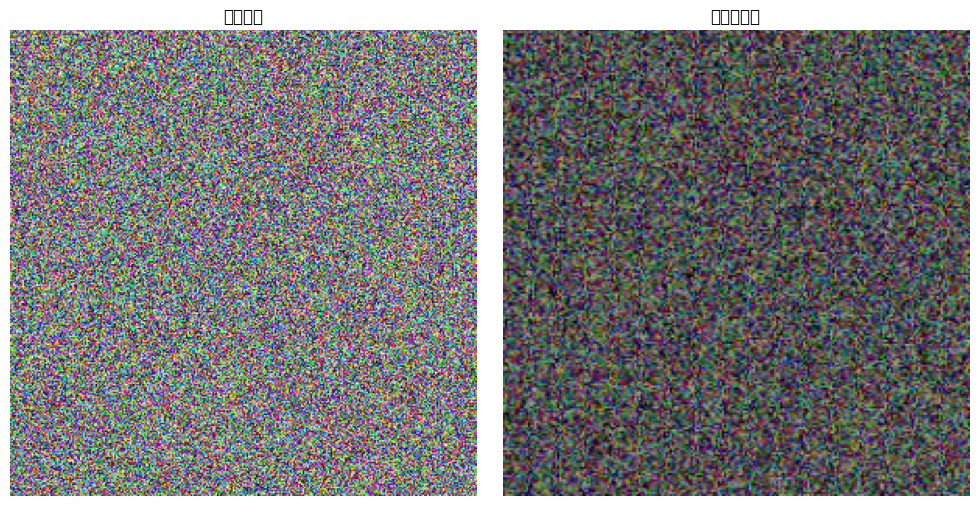

In [8]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# 创建组合图像增广管道
transform_pipeline = transforms.Compose([
    # 1. 随机裁剪，面积比例在 0.08 到 1.0 之间，缩放到 224×224
    transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
    
    # 2. 50% 概率水平翻转
    transforms.RandomHorizontalFlip(p=0.5),
    
    # 3. 随机改变亮度、对比度、饱和度，变化范围 0.5
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    
    # 4. 转换为张量
    transforms.ToTensor()
])

# ========== 测试输出 ==========
if __name__ == "__main__":
    # 创建一张示例图像（224×224 的 RGB 随机图像模拟真实输入）
    # 实际使用时替换为真实图片路径，如 Image.open("your_image.jpg")
    # img = Image.open("your_image.jpg").convert("RGB")
    
    # 这里用随机生成的图像作为示例
    img = Image.fromarray(
        (np.random.rand(300, 300, 3) * 255).astype(np.uint8)
    ).convert("RGB")
    
    print("=" * 50)
    print("图像增广管道测试")
    print("=" * 50)
    print(f"原始图像尺寸: {img.size}")
    
    # 应用图像增广管道 5 次，观察每次的输出差异
    for i in range(5):
        augmented_img = transform_pipeline(img)
        print(f"第 {i+1} 次增广 - 张量形状: {augmented_img.shape}, "
              f"数值范围: [{augmented_img.min():.3f}, {augmented_img.max():.3f}]")
    
    # 可视化对比（仅展示第 1 次增广结果）
    augmented_img = transform_pipeline(img)
    
    # 将张量转换回 PIL 图像以便显示
    to_pil = transforms.ToPILImage()
    augmented_pil = to_pil(augmented_img)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[0].set_title("原始图像")
    axes[0].axis("off")
    
    axes[1].imshow(augmented_pil)
    axes[1].set_title("增广后图像")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

## 6.1 理论计算题

在目标检测中，交并比（IoU）用于衡量预测边界框与真实边界框的重合程度。已知图像中两个边界框（以 `[左上角 x, 左上角 y, 右下角 x, 右下角 y]` 格式表示）：

- 真实框（Ground Truth）A = [10, 10, 50, 50]
- 预测框（Prediction Box）B = [30, 30, 70, 70]

请计算边界框 A 和边界框 B 之间的 IoU 准确值。

---

### 解：

**公式：**

IoU = 交集面积 / 并集面积 = |A ∩ B| / |A ∪ B|

---

**步骤 1：计算交集区域**

交集区域的左上角取两个框左上角的最大值，右下角取两个框右下角的最小值：

- 交集左上角 x：max(10, 30) = 30
- 交集左上角 y：max(10, 30) = 30
- 交集右下角 x：min(50, 70) = 50
- 交集右下角 y：min(50, 70) = 50

交集宽度：50 - 30 = 20  
交集高度：50 - 30 = 20  

交集面积：20 × 20 = 400

---

**步骤 2：计算各自的面积**

框 A 面积：
- 宽度：50 - 10 = 40
- 高度：50 - 10 = 40
- 面积：40 × 40 = 1600

框 B 面积：
- 宽度：70 - 30 = 40
- 高度：70 - 30 = 40
- 面积：40 × 40 = 1600

---

**步骤 3：计算并集面积**

并集面积 = 面积 A + 面积 B - 交集面积

|A ∪ B| = 1600 + 1600 - 400 = 2800

---

**步骤 4：计算 IoU**

IoU = 400 / 2800 = 1/7 ≈ 0.1429

---

### 最终答案：

IoU = 1/7

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def label_smoothing_cross_entropy(logits, target, epsilon=0.1):
    """
    计算标签平滑后的交叉熵损失
    
    参数:
        logits: 模型输出，形状为 (batch_size, num_classes)，未经过 softmax
        target: 真实标签，形状为 (batch_size,)，每个元素为类别的整数索引
        epsilon: 平滑因子，默认为 0.1
    
    返回:
        标签平滑后的交叉熵损失值
    """
    num_classes = logits.size(1)
    
    # 对 logits 计算 log softmax
    log_probs = F.log_softmax(logits, dim=1)
    
    # 构造平滑后的目标概率分布
    # 正确类别的概率: 1 - epsilon
    # 错误类别的概率: epsilon / (num_classes - 1)
    smooth_target = torch.full_like(log_probs, epsilon / (num_classes - 1))
    smooth_target.scatter_(1, target.unsqueeze(1), 1 - epsilon)
    
    # 计算交叉熵损失: -sum(target * log_probs)
    loss = - (smooth_target * log_probs).sum(dim=1).mean()
    
    return loss


# ========== 测试输出 ==========
if __name__ == "__main__":
    # 模拟数据：batch_size=4, num_classes=5
    logits = torch.randn(4, 5)
    target = torch.tensor([0, 2, 4, 1])
    
    # 普通交叉熵损失（用于对比）
    criterion_ce = nn.CrossEntropyLoss()
    loss_ce = criterion_ce(logits, target)
    
    # 标签平滑交叉熵损失
    loss_ls = label_smoothing_cross_entropy(logits, target, epsilon=0.1)
    
    print("=" * 50)
    print("标签平滑交叉熵损失测试")
    print("=" * 50)
    print(f"logits 形状: {logits.shape}")
    print(f"真实标签: {target}")
    print()
    print(f"普通交叉熵损失: {loss_ce.item():.4f}")
    print(f"标签平滑交叉熵损失 (ε=0.1): {loss_ls.item():.4f}")
    print()
    
    # 验证不同 epsilon 的效果
    print("-" * 50)
    print("不同平滑因子的效果对比:")
    for eps in [0.0, 0.05, 0.1, 0.2]:
        loss = label_smoothing_cross_entropy(logits, target, epsilon=eps)
        print(f"  epsilon = {eps:.2f}: loss = {loss.item():.4f}")
    print()
    print("说明: epsilon=0.0 时等价于普通交叉熵")

标签平滑交叉熵损失测试
logits 形状: torch.Size([4, 5])
真实标签: tensor([0, 2, 4, 1])

普通交叉熵损失: 2.3320
标签平滑交叉熵损失 (ε=0.1): 2.2825

--------------------------------------------------
不同平滑因子的效果对比:
  epsilon = 0.00: loss = 2.3320
  epsilon = 0.05: loss = 2.3072
  epsilon = 0.10: loss = 2.2825
  epsilon = 0.20: loss = 2.2330

说明: epsilon=0.0 时等价于普通交叉熵
